# Day 5 — Tuning, Evaluation & Sprint Review

## Overview

This notebook completes the Deep Learning phase of Sprint 1 for the
Cardiovascular Disease Prediction project.

The main focus is to systematically tune the neural network, evaluate its
performance using multiple classification metrics, and compare the final
model against the previously established supervised learning baselines.

The tuning process follows a one-variable-at-a-time approach to understand
the effect of each hyperparameter on model performance.

## Objectives

- Tune the neural network systematically using one hyperparameter at a time.
- Evaluate the effect of learning rate, network architecture, dropout, and batch size.
- Use EarlyStopping to prevent unnecessary training and overfitting.
- Use ModelCheckpoint to preserve the best-performing model.
- Evaluate the final model using Accuracy, Precision, Recall, and F1-score.
- Compare the neural network with the Logistic Regression baseline and the
  best supervised learning model.
- Analyze training and validation loss curves.
- Document the Sprint 1 results and prepare the final Sprint Review.

## Evaluation Strategy

The primary metric for comparing classification performance will be the
F1-score, while Accuracy, Precision, Recall, and validation loss will also
be monitored.

F1-score is particularly useful because it provides a balance between
Precision and Recall. Recall is also important in this project because
failing to identify a patient with cardiovascular disease can be more
serious than producing a false positive prediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [3]:
# Load the cleaned cardiovascular dataset
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [4]:
# Define original features and target
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Feature shape:", X.shape)
print("Features:", X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (68742, 11)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']

Target distribution:
cardio
0    34720
1    34022
Name: count, dtype: int64


In [5]:
# First split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (43994, 11)
Validation set: (10999, 11)
Test set: (13749, 11)


In [6]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (43994, 11)
Scaled validation shape: (10999, 11)
Scaled test shape: (13749, 11)


## Baseline Neural Network

A baseline neural network is trained using the original features before
applying any feature engineering.

The purpose of this model is to establish a reference performance that can
later be compared with the improved model.

In [7]:
# Build baseline neural network
baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[baseline_early_stopping],
    verbose=1
)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7200 - loss: 0.5634 - val_accuracy: 0.7279 - val_loss: 0.5509
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7314 - loss: 0.5474 - val_accuracy: 0.7291 - val_loss: 0.5473
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7331 - loss: 0.5454 - val_accuracy: 0.7289 - val_loss: 0.5487
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7338 - loss: 0.5441 - val_accuracy: 0.7290 - val_loss: 0.5474
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7340 - loss: 0.5431 - val_accuracy: 0.7333 - val_loss: 0.5467
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7358 - loss: 0.5421 - val_accuracy: 0.7315 - val_loss: 0.5459
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7350 - loss: 0.5416 - val_accuracy: 0.7306 - val_loss: 0.5459
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7354 - loss: 0.5409 - 

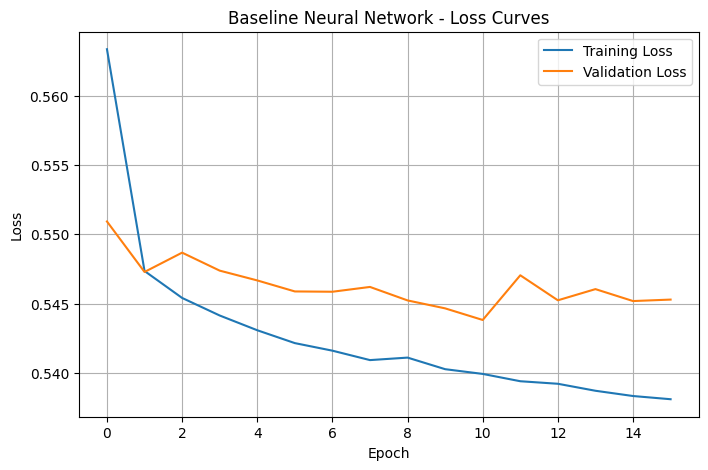

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Neural Network - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

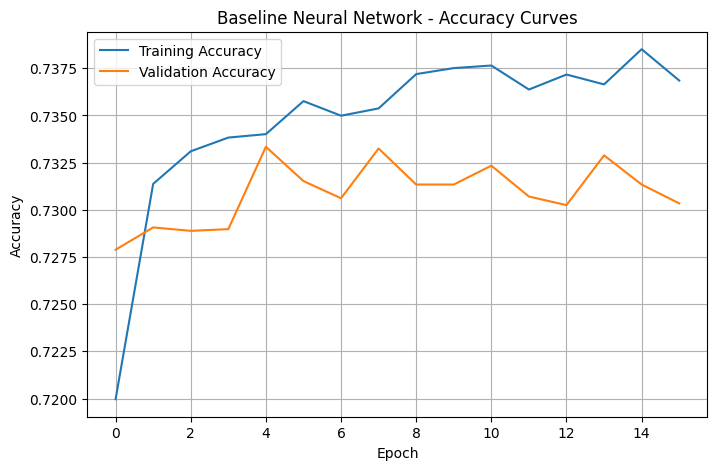

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Neural Network - Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

##  Baseline Evaluation

The baseline neural network is evaluated on the validation set using
Accuracy, Precision, Recall, and F1-score.

F1-score is used as the main comparison metric for the later experiments.

In [11]:
# Predict validation probabilities
y_val_prob_baseline = baseline_model.predict(
    X_val_scaled,
    verbose=0
)

# Convert probabilities to class predictions
y_val_pred_baseline = (
    y_val_prob_baseline >= 0.5
).astype(int).ravel()

# Calculate metrics
baseline_val_accuracy = accuracy_score(
    y_val,
    y_val_pred_baseline
)

baseline_val_precision = precision_score(
    y_val,
    y_val_pred_baseline
)

baseline_val_recall = recall_score(
    y_val,
    y_val_pred_baseline
)

baseline_val_f1 = f1_score(
    y_val,
    y_val_pred_baseline
)

print("Baseline Neural Network - Validation Results")
print("-" * 48)
print(f"Accuracy : {baseline_val_accuracy:.4f}")
print(f"Precision: {baseline_val_precision:.4f}")
print(f"Recall   : {baseline_val_recall:.4f}")
print(f"F1-score : {baseline_val_f1:.4f}")

Baseline Neural Network - Validation Results
------------------------------------------------
Accuracy : 0.7323
Precision: 0.7520
Recall   : 0.6852
F1-score : 0.7170


##  Baseline vs Final Test Comparison

To ensure a fair comparison, both models are evaluated on the same unseen
test set.

This comparison measures whether feature engineering and hyperparameter
tuning improved the model's ability to generalize to unseen data.

In [41]:
# Evaluate the baseline model on the unseen test set
y_test_prob_baseline = baseline_model.predict(
    X_test_scaled,
    verbose=0
)

y_test_pred_baseline = (
    y_test_prob_baseline >= 0.5
).astype(int).ravel()

baseline_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_baseline
)

baseline_test_precision = precision_score(
    y_test,
    y_test_pred_baseline
)

baseline_test_recall = recall_score(
    y_test,
    y_test_pred_baseline
)

baseline_test_f1 = f1_score(
    y_test,
    y_test_pred_baseline
)

print("Baseline Neural Network - Test Results")
print("-" * 50)
print(f"Accuracy : {baseline_test_accuracy:.4f}")
print(f"Precision: {baseline_test_precision:.4f}")
print(f"Recall   : {baseline_test_recall:.4f}")
print(f"F1-score : {baseline_test_f1:.4f}")

Baseline Neural Network - Test Results
--------------------------------------------------
Accuracy : 0.7350
Precision: 0.7532
Recall   : 0.6908
F1-score : 0.7207


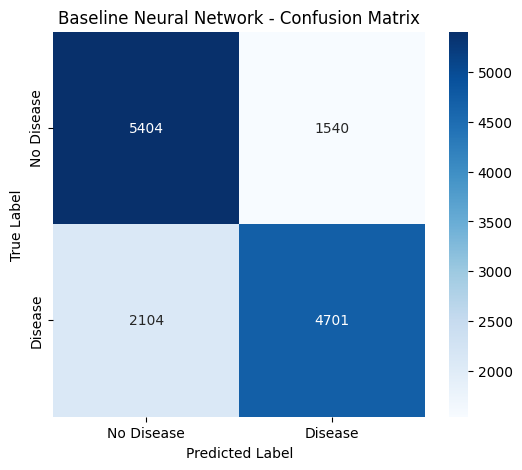

In [44]:
# Baseline confusion matrix
cm_baseline = confusion_matrix(
    y_test,
    y_test_pred_baseline
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline Neural Network - Confusion Matrix")

plt.show()

##  Data Quality Analysis — Blood Pressure

Before applying feature engineering, the original features are examined
for possible data quality issues.

Systolic blood pressure (`ap_hi`) should generally be higher than diastolic
blood pressure (`ap_lo`). Therefore, rows where `ap_hi <= ap_lo` are
identified and analyzed before deciding how to handle them.

In [12]:
# Identify inconsistent blood pressure records
bp_invalid = df[df["ap_hi"] <= df["ap_lo"]]

print("Number of inconsistent BP rows:", len(bp_invalid))

print(
    f"Percentage of inconsistent BP rows: "
    f"{len(bp_invalid) / len(df) * 100:.2f}%"
)

print("\nExamples:")
display(
    bp_invalid[["ap_hi", "ap_lo", "cardio"]].head(10)
)

Number of inconsistent BP rows: 103
Percentage of inconsistent BP rows: 0.15%

Examples:


,ap_hi,ap_lo,cardio
466,120,150,0
625,70,110,0
2339,90,150,1
2928,80,140,1
3380,80,125,1
3553,80,120,0
4730,90,140,1
4735,70,100,0
4846,80,170,1
5026,90,140,1


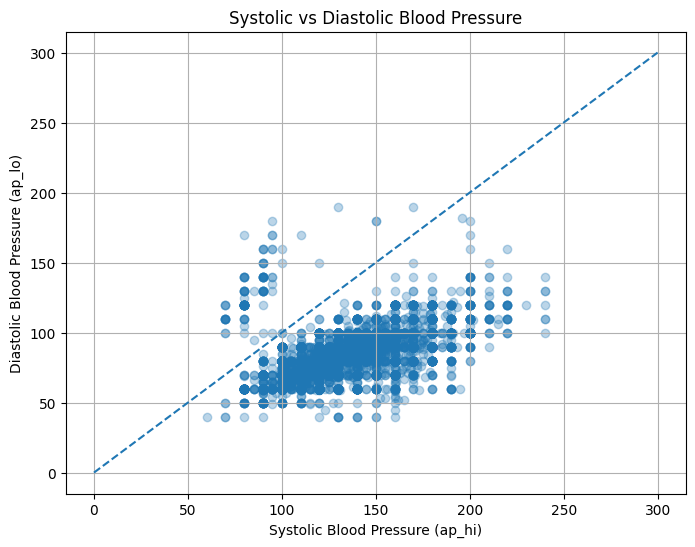

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["ap_hi"],
    df["ap_lo"],
    alpha=0.3
)

plt.plot(
    [0, 300],
    [0, 300],
    linestyle="--"
)

plt.xlabel("Systolic Blood Pressure (ap_hi)")
plt.ylabel("Diastolic Blood Pressure (ap_lo)")
plt.title("Systolic vs Diastolic Blood Pressure")

plt.grid(True)
plt.show()

In [14]:
# Remove inconsistent blood pressure records
df_fe = df[df["ap_hi"] > df["ap_lo"]].copy()

print("Original dataset shape:", df.shape)
print("After BP cleaning:", df_fe.shape)

print(
    "\nRemaining inconsistent BP rows:",
    (df_fe["ap_hi"] <= df_fe["ap_lo"]).sum()
)

Original dataset shape: (68742, 13)
After BP cleaning: (68639, 13)

Remaining inconsistent BP rows: 0


## Feature Engineering

Feature engineering is applied to create additional informative variables
from the existing clinical measurements.

The new features are designed to provide more meaningful representations of
body composition and blood pressure characteristics.

The following features are created:

- BMI: body mass index calculated from weight and height.
- Pulse Pressure: the difference between systolic and diastolic blood
  pressure.
- Mean Arterial Pressure: an approximate measure of average arterial pressure.

In [15]:
# Feature Engineering

# BMI
df_fe["bmi"] = (
    df_fe["weight"] /
    (df_fe["height"] / 100) ** 2
)

# Pulse Pressure
df_fe["pulse_pressure"] = (
    df_fe["ap_hi"] - df_fe["ap_lo"]
)

# Mean Arterial Pressure
df_fe["mean_arterial_pressure"] = (
    df_fe["ap_lo"] +
    (df_fe["ap_hi"] - df_fe["ap_lo"]) / 3
)

# Check the new features
display(
    df_fe[
        [
            "height",
            "weight",
            "ap_hi",
            "ap_lo",
            "bmi",
            "pulse_pressure",
            "mean_arterial_pressure"
        ]
    ].head()
)

,height,weight,ap_hi,ap_lo,bmi,pulse_pressure,mean_arterial_pressure
0,168,62.0,110,80,21.967120,30,90.000000
1,156,85.0,140,90,34.927679,50,106.666667
2,165,64.0,130,70,23.507805,60,90.000000
3,169,82.0,150,100,28.710479,50,116.666667
4,156,56.0,100,60,23.011177,40,73.333333


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define features and target
X_fe = df_fe.drop(columns=["cardio", "id"])
y_fe = df_fe["cardio"]

# Categorical features
categorical_features = [
    "gender",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active"
]

# Numerical features
numerical_features = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "bmi",
    "pulse_pressure",
    "mean_arterial_pressure"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Total original features:", X_fe.shape[1])

Categorical features: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
Numerical features: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'mean_arterial_pressure']
Total original features: 14


In [17]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

X_train_final_fe, X_val_fe, y_train_final_fe, y_val_fe = train_test_split(
    X_train_fe,
    y_train_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_train_fe
)

print("Training:", X_train_final_fe.shape)
print("Validation:", X_val_fe.shape)
print("Test:", X_test_fe.shape)

Training: (43928, 14)
Validation: (10983, 14)
Test: (13728, 14)


In [18]:
# Preprocessing pipeline
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_fe_scaled = preprocessor_fe.fit_transform(
    X_train_final_fe
)

# Transform validation and test data
X_val_fe_scaled = preprocessor_fe.transform(
    X_val_fe
)

X_test_fe_scaled = preprocessor_fe.transform(
    X_test_fe
)

print("Training shape after preprocessing:", X_train_fe_scaled.shape)
print("Validation shape after preprocessing:", X_val_fe_scaled.shape)
print("Test shape after preprocessing:", X_test_fe_scaled.shape)

Training shape after preprocessing: (43928, 22)
Validation shape after preprocessing: (10983, 22)
Test shape after preprocessing: (13728, 22)


##  Improved Neural Network

A second neural network is trained using the engineered features and
one-hot encoded categorical variables.

The same baseline architecture and training configuration are used so that
the effect of data cleaning, feature engineering, and encoding can be
evaluated fairly.

The new model is then compared with the original baseline using the same
validation metrics.

In [19]:
# Build improved neural network
improved_model = Sequential([
    Input(shape=(X_train_fe_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Early Stopping
improved_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train improved model
history_improved = improved_model.fit(
    X_train_fe_scaled,
    y_train_final_fe,
    validation_data=(X_val_fe_scaled, y_val_fe),
    epochs=30,
    batch_size=32,
    callbacks=[improved_early_stopping],
    verbose=1
)

Epoch 1/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7241 - loss: 0.5573 - val_accuracy: 0.7318 - val_loss: 0.5469
Epoch 2/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7338 - loss: 0.5437 - val_accuracy: 0.7319 - val_loss: 0.5460
Epoch 3/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7351 - loss: 0.5422 - val_accuracy: 0.7346 - val_loss: 0.5451
Epoch 4/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7343 - loss: 0.5415 - val_accuracy: 0.7342 - val_loss: 0.5444
Epoch 5/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7362 - loss: 0.5403 - val_accuracy: 0.7354 - val_loss: 0.5445
Epoch 6/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7366 - loss: 0.5398 - val_accuracy: 0.7327 - val_loss: 0.5457
Epoch 7/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7360 - loss: 0.5398 - val_accuracy: 0.7347 - val_loss: 0.5447
Epoch 8/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7362 - loss: 0.5391 - 

In [21]:
# Predict validation probabilities
y_val_prob_improved = improved_model.predict(
    X_val_fe_scaled,
    verbose=0
)

# Convert probabilities to predictions
y_val_pred_improved = (
    y_val_prob_improved >= 0.5
).astype(int).ravel()

# Calculate metrics
improved_val_accuracy = accuracy_score(
    y_val_fe,
    y_val_pred_improved
)

improved_val_precision = precision_score(
    y_val_fe,
    y_val_pred_improved
)

improved_val_recall = recall_score(
    y_val_fe,
    y_val_pred_improved
)

improved_val_f1 = f1_score(
    y_val_fe,
    y_val_pred_improved
)

print("Improved Neural Network - Validation Results")
print("-" * 50)
print(f"Accuracy : {improved_val_accuracy:.4f}")
print(f"Precision: {improved_val_precision:.4f}")
print(f"Recall   : {improved_val_recall:.4f}")
print(f"F1-score : {improved_val_f1:.4f}")

Improved Neural Network - Validation Results
--------------------------------------------------
Accuracy : 0.7342
Precision: 0.7565
Recall   : 0.6826
F1-score : 0.7176


##  Hyperparameter Tuning

After applying data quality improvements, feature engineering, and
one-hot encoding, hyperparameter tuning is repeated on the improved dataset.

A one-variable-at-a-time strategy is used to evaluate the effect of:

1. Learning Rate
2. Network Architecture
3. Dropout Rate
4. Batch Size

Validation F1-score is used as the primary metric for selecting the best
configuration, while Accuracy, Precision, Recall, and Validation Loss are
also monitored.

In [23]:
def build_model(
    learning_rate=0.001,
    hidden_layers=(32, 16),
    dropout_rate=0.0
):
    model = Sequential([
        Input(shape=(X_train_fe_scaled.shape[1],)),
        Dense(hidden_layers[0], activation="relu")
    ])

    # Add remaining hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))

    # Add dropout when needed
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:
def evaluate_model(model, X_data, y_data):
    probabilities = model.predict(
        X_data,
        verbose=0
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int).ravel()

    return {
        "Accuracy": accuracy_score(
            y_data,
            predictions
        ),
        "Precision": precision_score(
            y_data,
            predictions
        ),
        "Recall": recall_score(
            y_data,
            predictions
        ),
        "F1": f1_score(
            y_data,
            predictions
        )
    }

In [25]:
learning_rates_fe = [0.01, 0.001, 0.0005, 0.0001]

learning_rate_results_fe = []

for lr in learning_rates_fe:

    print(f"Training model with learning rate = {lr}")

    model = build_model(
        learning_rate=lr,
        hidden_layers=(32, 16),
        dropout_rate=0.0
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_fe_scaled,
        y_train_final_fe,
        validation_data=(X_val_fe_scaled, y_val_fe),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(
        model,
        X_val_fe_scaled,
        y_val_fe
    )

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    learning_rate_results_fe.append({
        "Learning Rate": lr,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

learning_rate_results_fe_df = pd.DataFrame(
    learning_rate_results_fe
)

learning_rate_results_fe_df

Training model with learning rate = 0.01
Training model with learning rate = 0.001
Training model with learning rate = 0.0005
Training model with learning rate = 0.0001


,Learning Rate,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,0.0100,5,0.542737,0.732860,0.750903,0.688443,0.718318
1,0.0010,2,0.543498,0.735500,0.760453,0.679426,0.717660
2,0.0005,11,0.543130,0.735682,0.741369,0.715311,0.728107
3,0.0001,18,0.544298,0.732860,0.754168,0.682554,0.716577


### Network Architecture Tuning

After selecting the best learning rate, different neural network
architectures are evaluated while keeping the learning rate fixed.

The architectures are compared using Validation F1-score as the primary
selection metric.

In [27]:
# Set the best learning rate selected from the previous experiment
best_learning_rate_fe = 0.0005

print("Selected Learning Rate:", best_learning_rate_fe)

Selected Learning Rate: 0.0005


In [28]:
architectures_fe = [
    (16, 8),
    (32, 16),
    (64, 32),
    (64, 32, 16),
    (128, 64, 32)
]

architecture_results_fe = []

for architecture in architectures_fe:

    print(f"\nTraining architecture = {architecture}")

    model = build_model(
        learning_rate=best_learning_rate_fe,
        hidden_layers=architecture,
        dropout_rate=0.0
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_fe_scaled,
        y_train_final_fe,
        validation_data=(X_val_fe_scaled, y_val_fe),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(
        model,
        X_val_fe_scaled,
        y_val_fe
    )

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    architecture_results_fe.append({
        "Architecture": str(architecture),
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

architecture_results_fe_df = pd.DataFrame(
    architecture_results_fe
)

architecture_results_fe_df


Training architecture = (16, 8)

Training architecture = (32, 16)

Training architecture = (64, 32)

Training architecture = (64, 32, 16)

Training architecture = (128, 64, 32)


,Architecture,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,"(16, 8)",7,0.543266,0.735318,0.752953,0.692124,0.721258
1,"(32, 16)",9,0.542290,0.735773,0.751990,0.695252,0.722509
2,"(64, 32)",5,0.543063,0.734226,0.753784,0.687339,0.719030
3,"(64, 32, 16)",7,0.543708,0.731676,0.736542,0.712551,0.724348
4,"(128, 64, 32)",4,0.542885,0.735318,0.754174,0.689915,0.720615


In [30]:
# Store the best architecture selected from the current experiment
best_architecture_fe = (64, 32, 16)

print("Selected Architecture:", best_architecture_fe)

Selected Architecture: (64, 32, 16)


###  Dropout Tuning

After selecting the best network architecture, different dropout rates are
evaluated while keeping the learning rate and architecture fixed.

Validation F1-score remains the primary metric for selecting the best
configuration.

In [31]:
dropout_rates_fe = [0.0, 0.2, 0.3, 0.5]

dropout_results_fe = []

for dropout in dropout_rates_fe:

    print(f"\nTraining model with dropout rate = {dropout}")

    model = build_model(
        learning_rate=best_learning_rate_fe,
        hidden_layers=best_architecture_fe,
        dropout_rate=dropout
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_fe_scaled,
        y_train_final_fe,
        validation_data=(X_val_fe_scaled, y_val_fe),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(
        model,
        X_val_fe_scaled,
        y_val_fe
    )

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    dropout_results_fe.append({
        "Dropout Rate": dropout,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

dropout_results_fe_df = pd.DataFrame(dropout_results_fe)

dropout_results_fe_df


Training model with dropout rate = 0.0

Training model with dropout rate = 0.2

Training model with dropout rate = 0.3

Training model with dropout rate = 0.5


,Dropout Rate,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,0.0,11,0.543377,0.735045,0.751194,0.694516,0.721744
1,0.2,9,0.542653,0.735956,0.744217,0.710526,0.726982
2,0.3,14,0.542490,0.734317,0.753527,0.688075,0.719315
3,0.5,9,0.542116,0.736866,0.760977,0.682554,0.719635


In [32]:
# Store the best dropout rate
best_dropout_rate_fe = 0.2

print("Selected Dropout Rate:", best_dropout_rate_fe)

Selected Dropout Rate: 0.2


###  Batch Size Tuning

After selecting the best learning rate, network architecture, and dropout
rate, different batch sizes are evaluated.

The Validation F1-score remains the primary metric for selecting the final
batch size.

In [33]:
batch_sizes_fe = [16, 32, 64, 128]

batch_size_results_fe = []

for batch_size in batch_sizes_fe:

    print(f"\nTraining model with batch size = {batch_size}")

    model = build_model(
        learning_rate=best_learning_rate_fe,
        hidden_layers=best_architecture_fe,
        dropout_rate=best_dropout_rate_fe
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_fe_scaled,
        y_train_final_fe,
        validation_data=(X_val_fe_scaled, y_val_fe),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(
        model,
        X_val_fe_scaled,
        y_val_fe
    )

    best_epoch = np.argmin(
        history.history["val_loss"]
    ) + 1

    batch_size_results_fe.append({
        "Batch Size": batch_size,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

batch_size_results_fe_df = pd.DataFrame(
    batch_size_results_fe
)

batch_size_results_fe_df


Training model with batch size = 16

Training model with batch size = 32

Training model with batch size = 64

Training model with batch size = 128


,Batch Size,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,16,13,0.542694,0.734772,0.753367,0.689731,0.720146
1,32,3,0.542587,0.736229,0.741573,0.716599,0.728872
2,64,16,0.542530,0.736502,0.747950,0.705006,0.725843
3,128,15,0.542379,0.735409,0.757644,0.684026,0.718956


In [35]:
# Final selected hyperparameters
best_learning_rate_fe = 0.0005
best_architecture_fe = (64, 32, 16)
best_dropout_rate_fe = 0.2
best_batch_size_fe = 32

print("Final Hyperparameters")
print("-" * 30)
print("Learning Rate :", best_learning_rate_fe)
print("Architecture  :", best_architecture_fe)
print("Dropout Rate  :", best_dropout_rate_fe)
print("Batch Size    :", best_batch_size_fe)

Final Hyperparameters
------------------------------
Learning Rate : 0.0005
Architecture  : (64, 32, 16)
Dropout Rate  : 0.2
Batch Size    : 32


##  Final Neural Network

The final neural network is built using the best hyperparameters selected
during the tuning experiments.

The model uses the engineered features and one-hot encoded categorical
variables.

EarlyStopping is used to stop training when validation loss stops improving,
while ModelCheckpoint saves the best-performing model.

In [36]:
# Build the final neural network
final_model_fe = build_model(
    learning_rate=best_learning_rate_fe,
    hidden_layers=best_architecture_fe,
    dropout_rate=best_dropout_rate_fe
)

# Early Stopping
final_early_stopping_fe = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Model Checkpoint
final_checkpoint_fe = ModelCheckpoint(
    "best_final_model_fe.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

# Train the final model
history_final_fe = final_model_fe.fit(
    X_train_fe_scaled,
    y_train_final_fe,
    validation_data=(X_val_fe_scaled, y_val_fe),
    epochs=50,
    batch_size=best_batch_size_fe,
    callbacks=[
        final_early_stopping_fe,
        final_checkpoint_fe
    ],
    verbose=1
)

Epoch 1/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7200 - loss: 0.5668 - val_accuracy: 0.7296 - val_loss: 0.5474
Epoch 2/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7335 - loss: 0.5524 - val_accuracy: 0.7349 - val_loss: 0.5464
Epoch 3/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7349 - loss: 0.5485 - val_accuracy: 0.7345 - val_loss: 0.5448
Epoch 4/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.7360 - loss: 0.5477 - val_accuracy: 0.7363 - val_loss: 0.5443
Epoch 5/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7366 - loss: 0.5459 - val_accuracy: 0.7344 - val_loss: 0.5445
Epoch 6/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7373 - loss: 0.5445 - val_accuracy: 0.7307 - val_loss: 0.5446
Epoch 7/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7378 - loss: 0.5433 - val_accuracy: 0.7359 - val_loss: 0.5436
Epoch 8/50
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7394 - loss: 0.5432

## Final Model Training Curves

The training and validation curves are analyzed to evaluate the learning
behavior of the final model and identify potential overfitting.

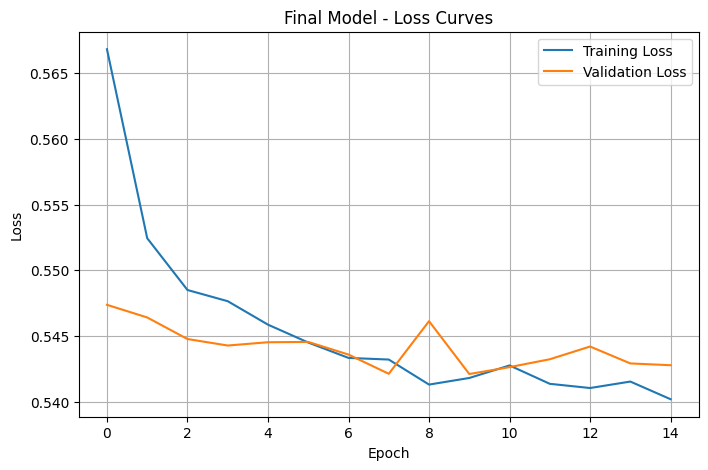

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final_fe.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_final_fe.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

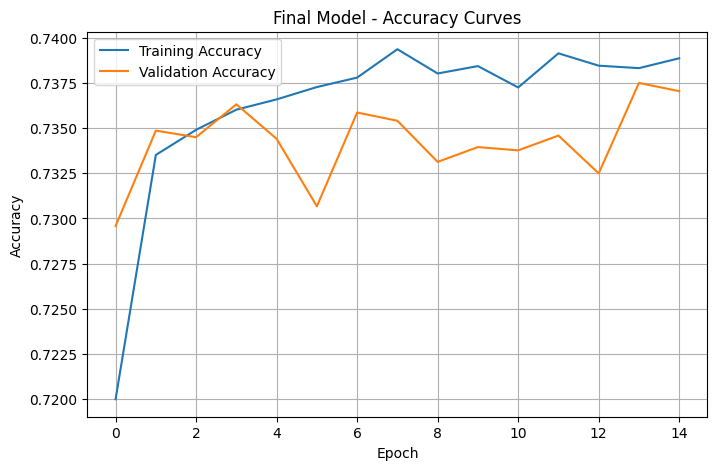

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final_fe.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_final_fe.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model - Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

##  Final Test Evaluation

The final tuned neural network is evaluated on the unseen test set.

The test set was not used during feature engineering decisions or
hyperparameter tuning. It is used only at this stage to provide an unbiased
estimate of the final model's performance.

The model is evaluated using Accuracy, Precision, Recall, and F1-score.

In [39]:
# Predict probabilities on the unseen test set
y_test_prob_fe = final_model_fe.predict(
    X_test_fe_scaled,
    verbose=0
)

# Convert probabilities to binary predictions
y_test_pred_fe = (
    y_test_prob_fe >= 0.5
).astype(int).ravel()

# Calculate final test metrics
final_test_accuracy_fe = accuracy_score(
    y_test_fe,
    y_test_pred_fe
)

final_test_precision_fe = precision_score(
    y_test_fe,
    y_test_pred_fe
)

final_test_recall_fe = recall_score(
    y_test_fe,
    y_test_pred_fe
)

final_test_f1_fe = f1_score(
    y_test_fe,
    y_test_pred_fe
)

print("Final Tuned Neural Network - Test Results")
print("-" * 50)
print(f"Accuracy : {final_test_accuracy_fe:.4f}")
print(f"Precision: {final_test_precision_fe:.4f}")
print(f"Recall   : {final_test_recall_fe:.4f}")
print(f"F1-score : {final_test_f1_fe:.4f}")

Final Tuned Neural Network - Test Results
--------------------------------------------------
Accuracy : 0.7271
Precision: 0.7520
Recall   : 0.6692
F1-score : 0.7082


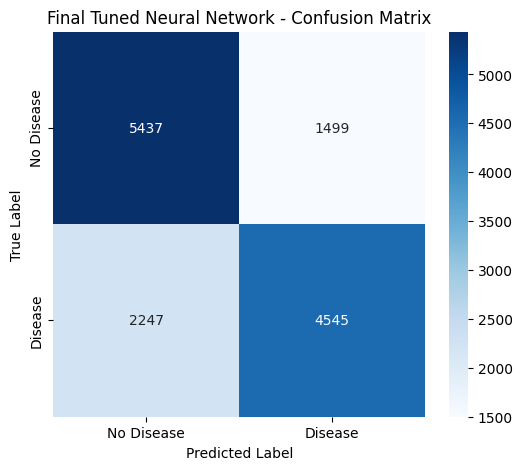

In [40]:
cm_final_fe = confusion_matrix(
    y_test_fe,
    y_test_pred_fe
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final_fe,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Tuned Neural Network - Confusion Matrix")

plt.show()

##  Final Model Comparison

The baseline and final tuned neural networks are compared using the same
unseen test set.

The comparison evaluates whether feature engineering, one-hot encoding, and
hyperparameter tuning improved the model's generalization performance.

In [42]:
# Final test-set comparison
final_comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Baseline": [
        baseline_test_accuracy,
        baseline_test_precision,
        baseline_test_recall,
        baseline_test_f1
    ],
    "Final Tuned Model": [
        final_test_accuracy_fe,
        final_test_precision_fe,
        final_test_recall_fe,
        final_test_f1_fe
    ]
})

# Calculate change
final_comparison_df["Change"] = (
    final_comparison_df["Final Tuned Model"]
    - final_comparison_df["Baseline"]
)

final_comparison_df.round(4)

,Metric,Baseline,Final Tuned Model,Change
0,Accuracy,0.7350,0.7271,-0.0078
1,Precision,0.7532,0.7520,-0.0013
2,Recall,0.6908,0.6692,-0.0216
3,F1-score,0.7207,0.7082,-0.0125


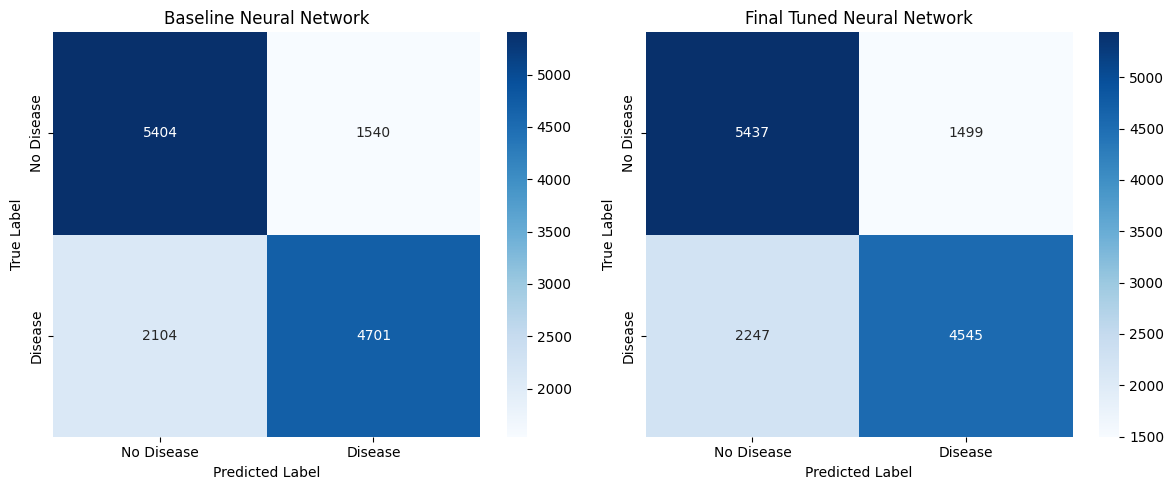

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    ax=axes[0]
)

axes[0].set_title("Baseline Neural Network")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Final Tuned
sns.heatmap(
    cm_final_fe,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    ax=axes[1]
)

axes[1].set_title("Final Tuned Neural Network")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

##  Final Conclusion

The neural network was first evaluated using the original dataset to establish
a baseline performance. The baseline model achieved **73.50% accuracy**,
**75.32% precision**, **69.08% recall**, and an **F1-score of 72.07%** on the
unseen test set.

Data quality analysis identified **103 records (0.15%)** where systolic blood
pressure (`ap_hi`) was lower than or equal to diastolic blood pressure
(`ap_lo`). These inconsistent records were removed before applying feature
engineering.

Additional features were then created, including **BMI, Pulse Pressure, and
Mean Arterial Pressure**, and categorical variables were one-hot encoded.
The model was subsequently tuned using a one-variable-at-a-time strategy.

The best configuration obtained during tuning used a learning rate of
**0.0005**, an architecture of **(64, 32, 16)**, a dropout rate of **0.2**,
and a batch size of **32**, with EarlyStopping and ModelCheckpoint enabled.

Although the tuned model achieved a higher validation F1-score during model
selection, the final test results were lower than those of the baseline
model. The final tuned model achieved **72.71% accuracy**, **75.20%
precision**, **66.92% recall**, and an **F1-score of 70.82%**.

The confusion matrix provides further insight into this result. It shows the
numbers of correctly classified and misclassified patients, including True
Negatives, False Positives, False Negatives, and True Positives. The lower
Recall of the tuned model indicates that it missed more positive
cardiovascular disease cases than the baseline model.

Overall, the experiments demonstrate that feature engineering and
hyperparameter tuning do not always improve generalization performance.
For this dataset, the original baseline neural network provided better
performance on unseen test data and is therefore retained as the better
performing neural network configuration.

This experiment highlights the importance of evaluating models on unseen
data rather than selecting a model based only on validation performance.
